In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [2]:
# plot target
def plot_target(ser_target):
    # get min/max
    flt_min = ser_target.min()
    flt_max = ser_target.max()
    # show distribution
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_title(f'Distribution of Target (N = {len(ser_target)}; Min = {flt_min:0.2f}; Max = {flt_max:0.2f})')
    sns.distplot(list(ser_target), ax=ax)
    # show
    plt.show()

/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


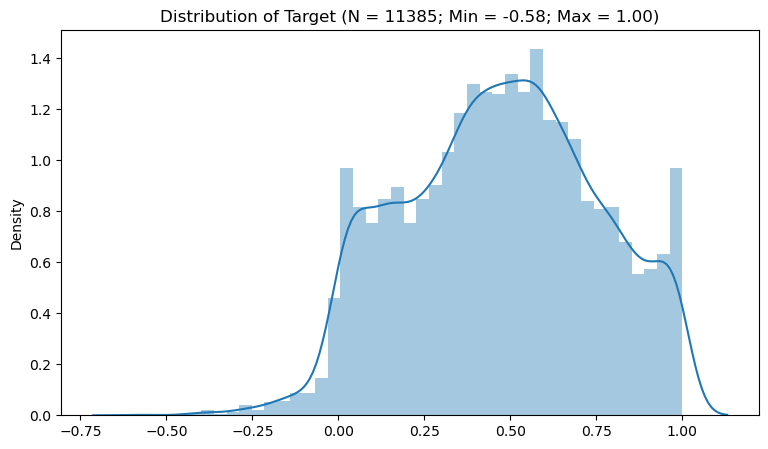

In [3]:
# no leaks
str_uri = 's3://20231010-gen-xii/03_pricing_lgd/01_data_prep/05_leaky_features/04_write_dfs/df_test_noleaks.gzip'
df_raw = pd.read_parquet(str_uri, columns=['target'])
plot_target(ser_target=df_raw['target'])

/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


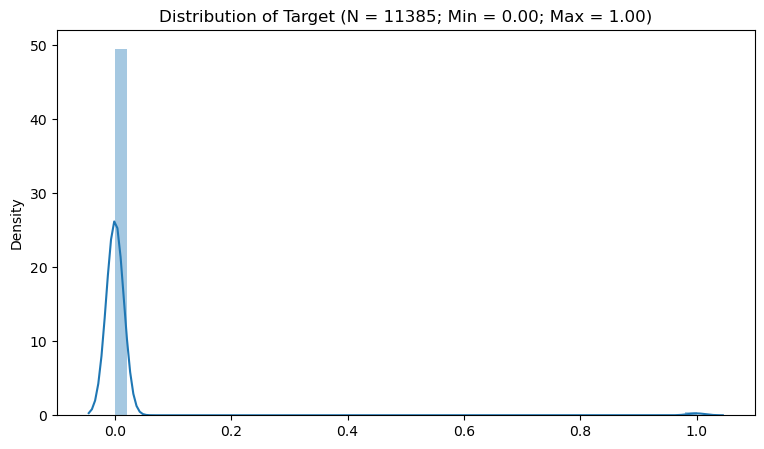

In [4]:
# preprocessed
str_uri = 's3://20231010-gen-xii/03_pricing_lgd/02_model/00_preprocessing/02_make_dfs/df_test_noleaks_pre.gzip'
df_pre = pd.read_parquet(str_uri, columns=['target'])
plot_target(ser_target=df_pre['target'])

In [5]:
df_pre['target'].value_counts()

target
0    11276
1      109
Name: count, dtype: int64

In [6]:
# preprocess
str_uri = 's3://20231010-gen-xii/03_pricing_lgd/01_data_prep/05_leaky_features/04_write_dfs/df_test_noleaks.gzip'
df_raw = pd.read_parquet(str_uri)

df_raw

,linkf189__tu,linkf060__tu,linkf045__tu,linkb012__tu,intservicecontractmileage__app,intservicecontractterm__app,inttype__app,linkf185__tu,linkf195__tu,linkf193__tu,...,strdealershiptrackertype__app,bitdealerapplicantsamezip__app,bitdealerapplicantsamecity__app,bitdealerapplicantsamestate__app,dealerstate__app,uniqueid,applicationdate__app,target,year_month,data_set
53722,NaN,NaN,NaN,NaN,70000.0,24.0,7.0,NaN,NaN,NaN,...,Franchise,0.0,0.0,0.0,Idaho,3.658316e+14,2018-05-10,0.461572,2018-05,test
53723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Franchise,0.0,0.0,1.0,Texas,3.658408e+14,2018-05-10,0.265297,2018-05,test
53724,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Franchise,0.0,0.0,1.0,Washington,3.658443e+14,2018-05-10,0.533736,2018-05,test
53726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110.0,1898.0,110.0,...,Franchise,0.0,0.0,1.0,Georgia,3.658469e+14,2018-05-10,0.152361,2018-05,test
53725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,110.0,1898.0,110.0,...,Franchise,0.0,0.0,1.0,Georgia,3.658469e+14,2018-05-10,0.152361,2018-05,test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2330,48.0,0.0,0.0,NaN,NaN,NaN,NaN,244.0,1358.0,48.0,...,Franchise,0.0,0.0,0.0,Washington,4.713884e+14,2019-10-25,0.317972,2019-10,test
255,NaN,NaN,NaN,0.0,0.0,24.0,NaN,NaN,NaN,NaN,...,Independent,0.0,0.0,1.0,Pennsylvania,4.713717e+14,2019-10-25,0.134430,2019-10,test
1466,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,Independent,0.0,0.0,1.0,Maryland,4.716592e+14,2019-10-26,0.052919,2019-10,test
5268,1493.0,0.0,0.0,NaN,NaN,NaN,NaN,1488.0,1493.0,1488.0,...,Franchise,0.0,1.0,1.0,Texas,4.715586e+14,2019-10-26,0.278619,2019-10,test


In [10]:
cls_model_preprocessing = pickle.load(open('cls_model_preprocessing.pkl', 'rb'))
cls_model_preprocessing

PreprocessingModel(list_transformers=[ReplaceNaNs(str_message='NaN Replacer'),
                                      ReplaceBooleans(str_message='Boolean '
                                                                  'Replacer'),
                                      SetDataTypes(),
                                      CleanText(list_cols=['city__tu',
                                                           'linkf001__tu',
                                                           'linkf032__tu',
                                                           'rvlr14__tu',
                                                           'rvlr15__tu',
                                                           'rvlr16__tu',
                                                           'rvlr17__tu',
                                                           'rvlr18__tu',
                                                           'rvlr19__tu',
                                                           'rvlr20__tu',
                                                           'rvlr21__tu',
                                                           'rvlr22__tu',
                                                           'rvlr23__tu',
                                                           'rvlr24__tu',
                                                           'rvl...
                                      ReplaceInf(str_message='Replace inf and '
                                                             '-inf with NaN'),
                                      Imputer(), MapTerm(), MapPTI(),
                                      RoundBinning(dict_round={'fltamountfinanced__app': 500,
                                                               'fltapproveddowntotal__app': 500,
                                                               'fltapprovedpricewholesale__app': 500,
                                                               'fltapprovedservicecontract__app': 500,
                                                               'fltdowncash__app': 500,
                                                               'fltgapinsurance__app': 500,
                                                               'intservicecontractmileage__app': 10000},
                                                   str_message='Round values')])

In [13]:
list_transformers = cls_model_preprocessing.list_transformers
list_transformers

[ReplaceNaNs(str_message='NaN Replacer'),
 ReplaceBooleans(str_message='Boolean Replacer'),
 SetDataTypes(),
 CleanText(list_cols=['city__tu', 'linkf001__tu', 'linkf032__tu', 'rvlr14__tu',
                      'rvlr15__tu', 'rvlr16__tu', 'rvlr17__tu', 'rvlr18__tu',
                      'rvlr19__tu', 'rvlr20__tu', 'rvlr21__tu', 'rvlr22__tu',
                      'rvlr23__tu', 'rvlr24__tu', 'rvlr25__tu', 'rvlr26__tu',
                      'rvlr27__tu', 'rvlr28__tu', 'rvlr78__tu', 'rvlr79__tu',
                      'rvlr80__tu', 'rvlr81__tu', 'bcpmtstr__tu', 'strcity__app',
                      'strname__app', 'strzipcode__app', 'bitsystemdecline__app',
                      'dtmstampcreation__app', 'dtmapproved__app',
                      'dtmdeclined__app', ...],
           str_message='Clean text and impute non-numeric'),
 Inflator(dict_inflation_rate={2013: 1.1343492088654628, 2014: 1.135868486844716,
                               2015: 1.136341981459793, 2016: 1.1425221287509

NaN Replacer: 0.053344 sec.
Preprocessing Model: 0.053446 sec.


/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


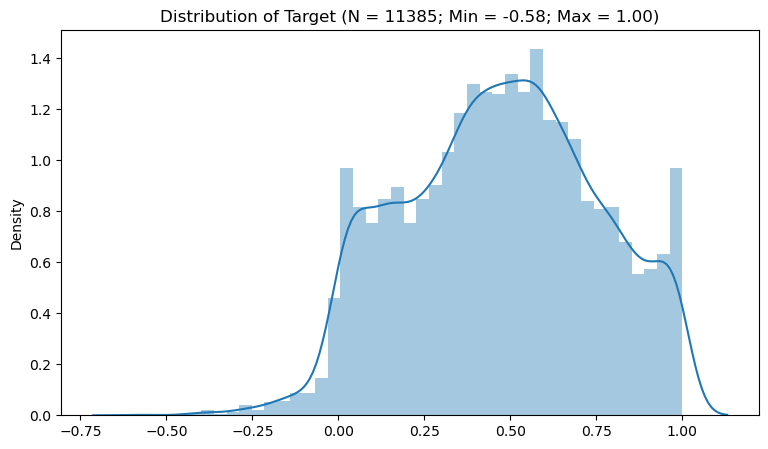

NaN Replacer: 0.053123 sec.
Boolean Replacer: 0.071705 sec.
Preprocessing Model: 0.12497 sec.


/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


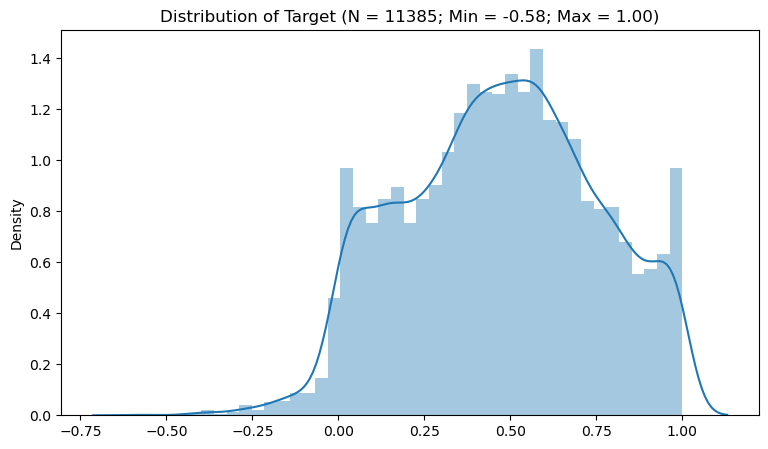

NaN Replacer: 0.053147 sec.
Boolean Replacer: 0.070906 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4321.38it/s]
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


Data Type Setter: 0.63318 sec.
Preprocessing Model: 0.75743 sec.


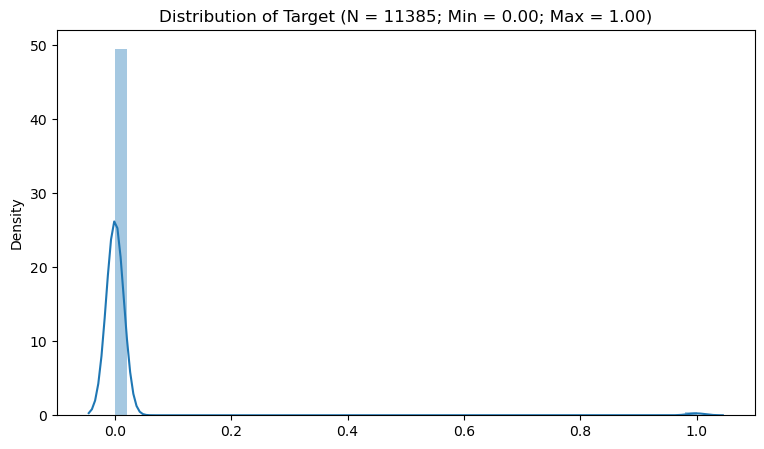

NaN Replacer: 0.053574 sec.
Boolean Replacer: 0.071028 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4486.00it/s]


Data Type Setter: 0.61982 sec.


100%|██████████| 32/32 [00:00<00:00, 122.26it/s]
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


Clean text and impute non-numeric: 0.27317 sec.
Preprocessing Model: 1.0178 sec.


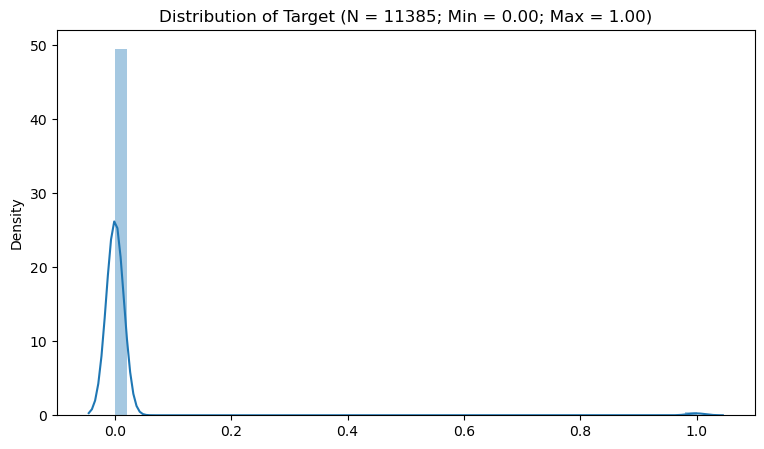

NaN Replacer: 0.053332 sec.
Boolean Replacer: 0.071574 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4460.44it/s]


Data Type Setter: 0.62156 sec.


100%|██████████| 32/32 [00:00<00:00, 126.20it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26449 sec.


100%|██████████| 15/15 [00:00<00:00, 2935.13it/s]
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


Inflate to 2021 dollars (automobiles only): 0.011362 sec.
Preprocessing Model: 1.0226 sec.


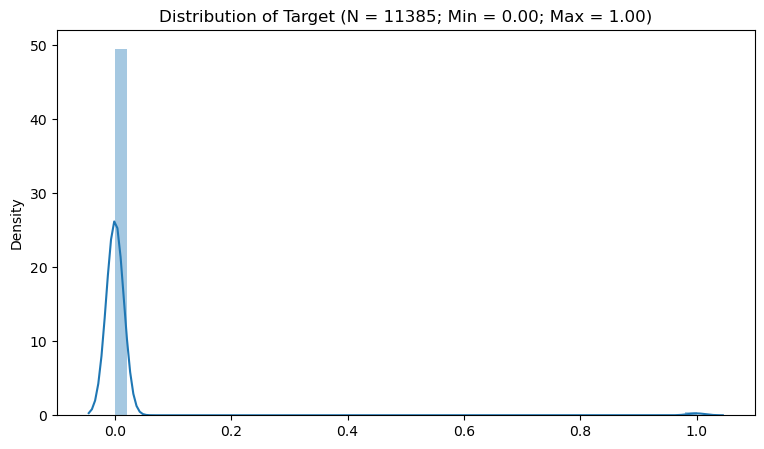

NaN Replacer: 0.053254 sec.
Boolean Replacer: 0.070783 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4446.07it/s]


Data Type Setter: 0.62515 sec.


100%|██████████| 32/32 [00:00<00:00, 125.62it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26574 sec.


100%|██████████| 15/15 [00:00<00:00, 2887.18it/s]


Inflate to 2021 dollars (automobiles only): 0.011679 sec.


100%|██████████| 263/263 [00:00<00:00, 3264.96it/s]


Inflate to 2021 dollars (non-automobile): 0.13573 sec.
Preprocessing Model: 1.1626 sec.


/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


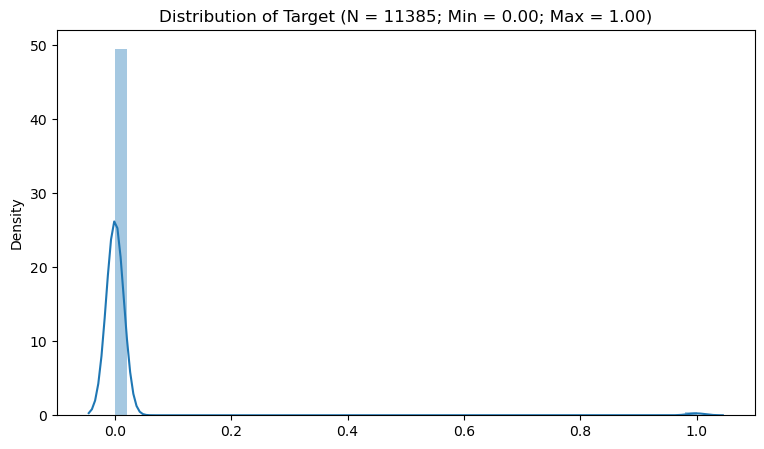

NaN Replacer: 0.053355 sec.
Boolean Replacer: 0.071623 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4461.61it/s]


Data Type Setter: 0.62258 sec.


100%|██████████| 32/32 [00:00<00:00, 125.54it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26552 sec.


...

Inflate to 2021 dollars (automobiles only): 0.01156 sec.


100%|██████████| 263/263 [00:00<00:00, 3279.78it/s]


Inflate to 2021 dollars (non-automobile): 0.13451 sec.


100%|██████████| 278/278 [00:00<00:00, 943.55it/s]
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


Clip negative dollar values to zero (automobile and non-automobile): 0.34963 sec.
Preprocessing Model: 1.5091 sec.


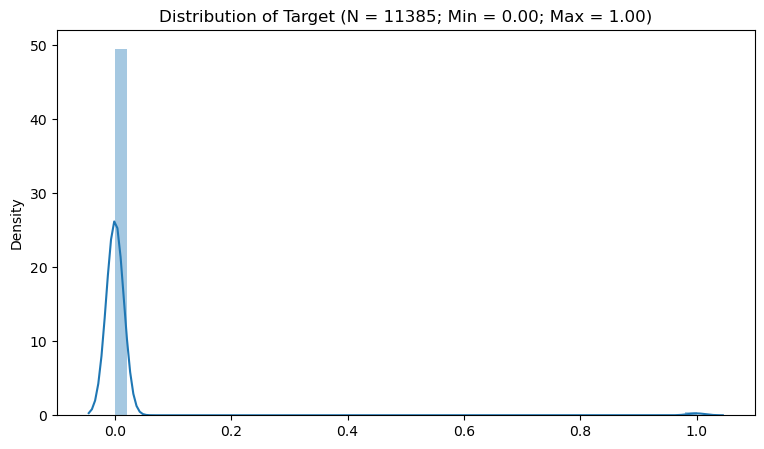

NaN Replacer: 0.054281 sec.
Boolean Replacer: 0.070756 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4461.88it/s]


Data Type Setter: 0.62147 sec.


100%|██████████| 32/32 [00:00<00:00, 125.55it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26598 sec.


...

Inflate to 2021 dollars (non-automobile): 0.13571 sec.


100%|██████████| 278/278 [00:00<00:00, 938.47it/s]


Clip negative dollar values to zero (automobile and non-automobile): 0.35042 sec.


100%|██████████| 1/1 [00:00<00:00, 504.85it/s]
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


Clip number of income sources to 2: 0.0037789 sec.
Preprocessing Model: 1.5143 sec.


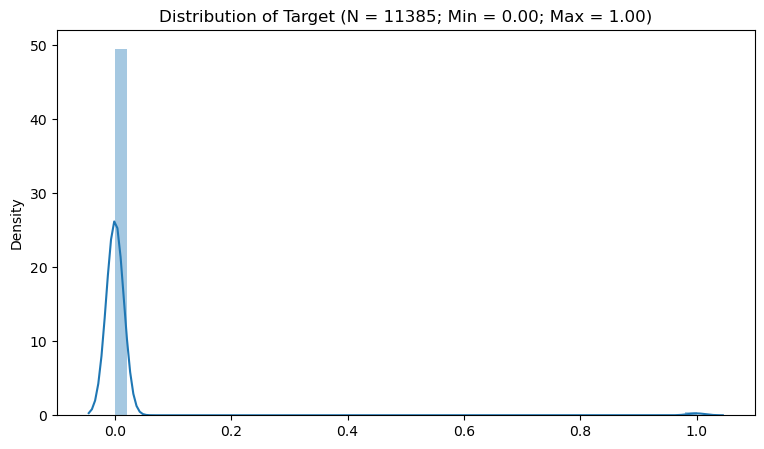

NaN Replacer: 0.053403 sec.
Boolean Replacer: 0.07118 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4443.04it/s]


Data Type Setter: 0.62574 sec.


100%|██████████| 32/32 [00:00<00:00, 125.44it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.2663 sec.


...

Clip negative dollar values to zero (automobile and non-automobile): 0.34827 sec.


100%|██████████| 1/1 [00:00<00:00, 521.10it/s]


Clip number of income sources to 2: 0.0037268 sec.


100%|██████████| 1/1 [00:00<00:00, 1160.57it/s]
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


Custom imputer: 0.002699 sec.
Preprocessing Model: 1.5178 sec.


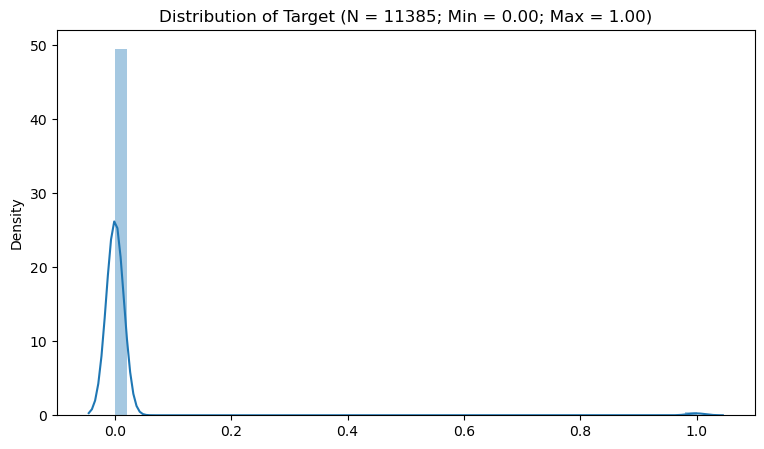

NaN Replacer: 0.053533 sec.
Boolean Replacer: 0.070574 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4471.02it/s]


Data Type Setter: 0.62072 sec.


100%|██████████| 32/32 [00:00<00:00, 125.09it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26657 sec.


...

100%|██████████| 1/1 [00:00<00:00, 519.42it/s]


Clip number of income sources to 2: 0.0036988 sec.


100%|██████████| 1/1 [00:00<00:00, 1244.23it/s]


Custom imputer: 0.0024371 sec.
Imputer: 0.26464 sec.
Preprocessing Model: 1.7726 sec.


/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


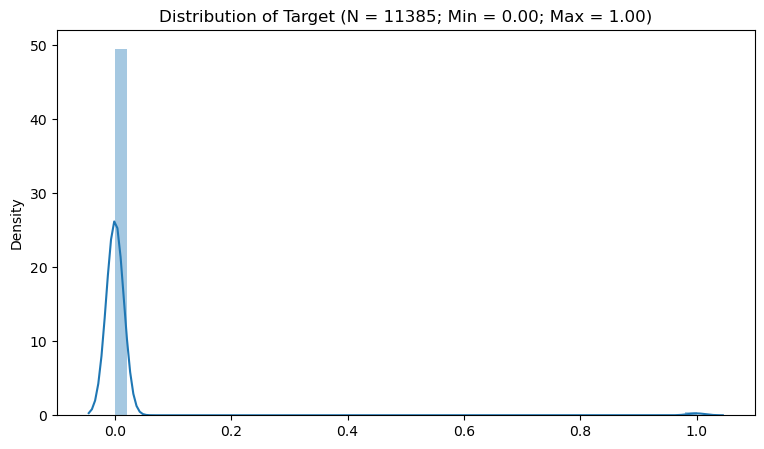

NaN Replacer: 0.054156 sec.
Boolean Replacer: 0.071353 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4470.35it/s]


Data Type Setter: 0.62084 sec.


100%|██████████| 32/32 [00:00<00:00, 124.66it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26755 sec.


...

100%|██████████| 1/1 [00:00<00:00, 1893.59it/s]


Custom imputer: 0.0026785 sec.
Imputer: 0.26629 sec.


100%|██████████| 2/2 [00:00<00:00, 1075.74it/s]

Replace zeros with predetermined value: 0.0039518 sec.
Preprocessing Model: 1.7872 sec.



/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


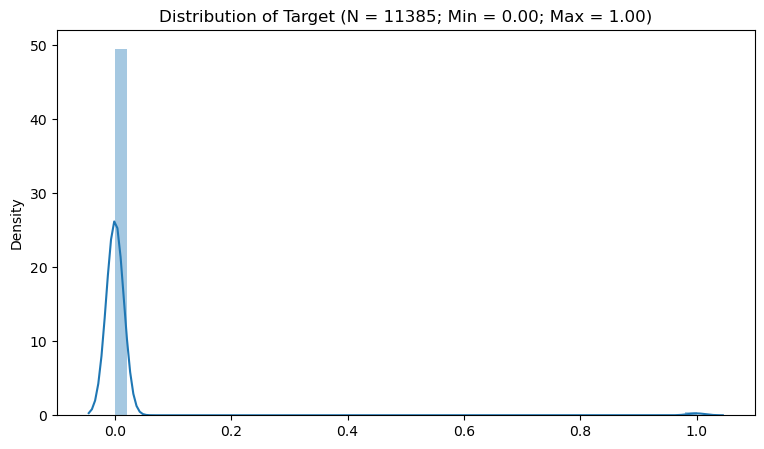

NaN Replacer: 0.053285 sec.
Boolean Replacer: 0.070519 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4373.99it/s]


Data Type Setter: 0.62646 sec.


100%|██████████| 32/32 [00:00<00:00, 124.26it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26846 sec.


...

100%|██████████| 1/1 [00:00<00:00, 1909.11it/s]


Custom imputer: 0.0026593 sec.
Imputer: 0.26727 sec.


100%|██████████| 2/2 [00:00<00:00, 1031.05it/s]

Replace zeros with predetermined value: 0.0040398 sec.
Date features: 0.011894 sec.
Preprocessing Model: 1.804 sec.



/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:341: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-applicationdate__app_month'] = X['applicationdate__app'].dt.month
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:342: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-applicationdate__app_quarter'] = X['applicationdate__app'].dt.quarter
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in sea

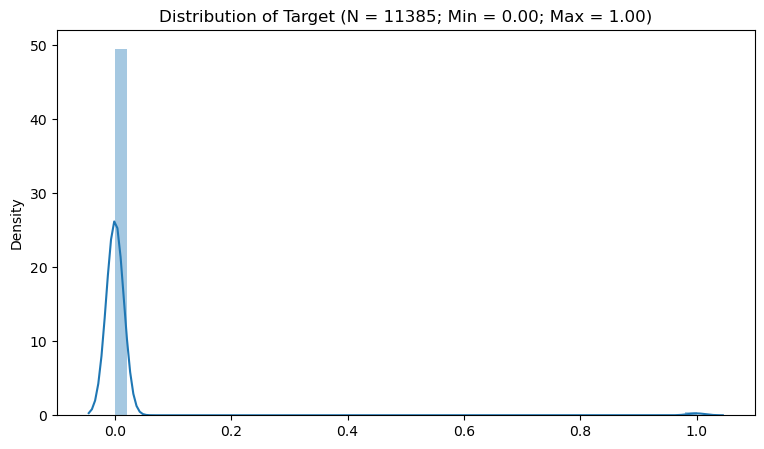

NaN Replacer: 0.053624 sec.
Boolean Replacer: 0.070761 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4424.22it/s]


Data Type Setter: 0.62478 sec.


100%|██████████| 32/32 [00:00<00:00, 123.63it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26964 sec.


...

100%|██████████| 2/2 [00:00<00:00, 1129.93it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:341: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-applicationdate__app_month'] = X['applicationdate__app'].dt.month
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:342: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-applicationdate__app_quarter'] = X['applicationdate__app'].dt.quarter


Replace zeros with predetermined value: 0.0038103 sec.
Date features: 0.11374 sec.


100%|██████████| 3/3 [00:00<00:00, 1416.36it/s]

Round income (for PTI), amount financed and vehicle values for (LTV): 0.0042116 sec.
Preprocessing Model: 1.8379 sec.



/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


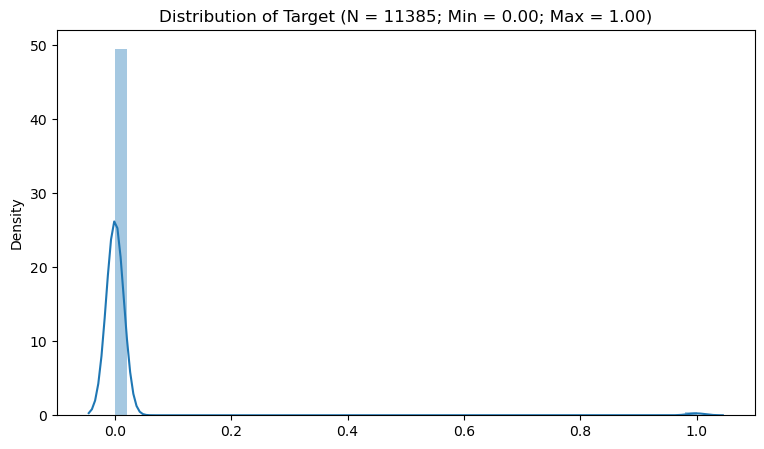

NaN Replacer: 0.053398 sec.
Boolean Replacer: 0.071061 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4450.79it/s]


Data Type Setter: 0.62333 sec.


100%|██████████| 32/32 [00:00<00:00, 124.66it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26751 sec.


...

100%|██████████| 2/2 [00:00<00:00, 1079.61it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:341: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-applicationdate__app_month'] = X['applicationdate__app'].dt.month
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:342: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-applicationdate__app_quarter'] = X['applicationdate__app'].dt.quarter


Replace zeros with predetermined value: 0.0039695 sec.
Date features: 0.011743 sec.


100%|██████████| 3/3 [00:00<00:00, 1425.66it/s]

Round income (for PTI), amount financed and vehicle values for (LTV): 0.0040397 sec.
Engineer PTI and LTV: 0.001969 sec.
Preprocessing Model: 1.8072 sec.



/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:404: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-payment_to_income'] = X['fltapprovedpayment__app'] / X['fltgrossmonthly__income_sum']
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-loan_to_value'] = X['fltamountfinanced__app'] / X['fltapprovedpricewholesale__app']
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated f

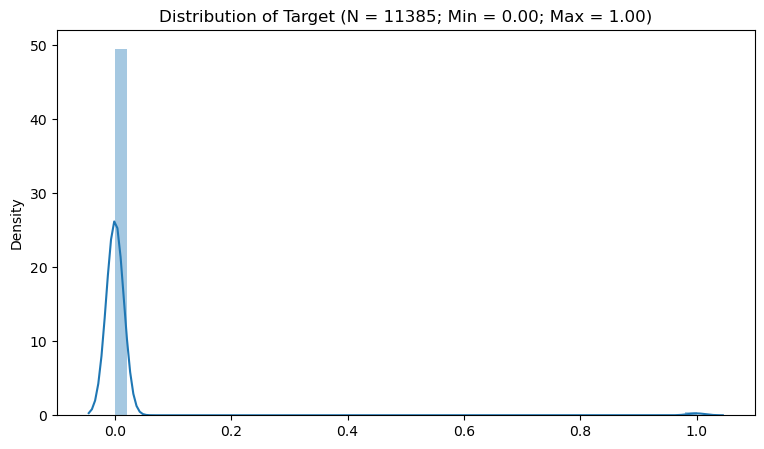

NaN Replacer: 0.053569 sec.
Boolean Replacer: 0.070935 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4391.54it/s]


Data Type Setter: 0.62661 sec.


100%|██████████| 32/32 [00:00<00:00, 123.90it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26917 sec.


...

Replace zeros with predetermined value: 0.0040107 sec.
Date features: 0.011828 sec.


100%|██████████| 3/3 [00:00<00:00, 1372.48it/s]

Round income (for PTI), amount financed and vehicle values for (LTV): 0.0040324 sec.
Engineer PTI and LTV: 0.001953 sec.



/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:404: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-payment_to_income'] = X['fltapprovedpayment__app'] / X['fltgrossmonthly__income_sum']
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-loan_to_value'] = X['fltamountfinanced__app'] / X['fltapprovedpricewholesale__app']
100%|██████████| 1556/1556 [00:00<00:00, 2551.49it/s]
/tmp/ipykernel_25340/285987

Replace inf and -inf with NaN: 0.8911 sec.
Preprocessing Model: 2.7014 sec.


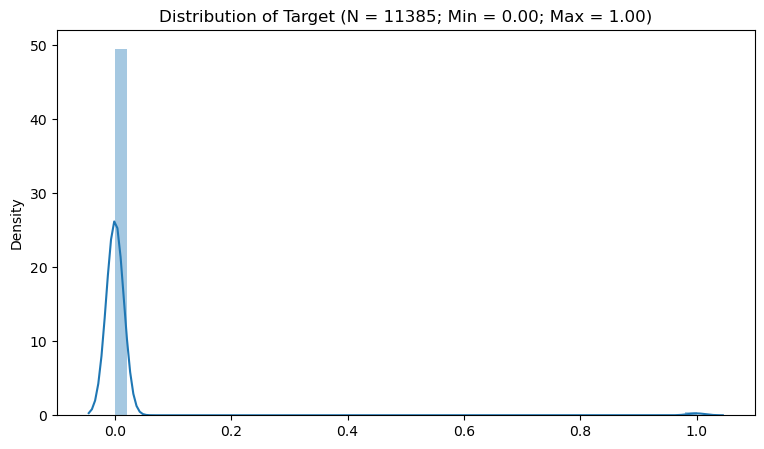

NaN Replacer: 0.053494 sec.
Boolean Replacer: 0.071881 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4395.92it/s]


Data Type Setter: 0.62688 sec.


100%|██████████| 32/32 [00:00<00:00, 123.67it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26941 sec.


...

Replace zeros with predetermined value: 0.0040326 sec.
Date features: 0.011784 sec.


100%|██████████| 3/3 [00:00<00:00, 1479.99it/s]

Round income (for PTI), amount financed and vehicle values for (LTV): 0.0040579 sec.
Engineer PTI and LTV: 0.0019601 sec.



/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:404: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-payment_to_income'] = X['fltapprovedpayment__app'] / X['fltgrossmonthly__income_sum']
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-loan_to_value'] = X['fltamountfinanced__app'] / X['fltapprovedpricewholesale__app']
100%|██████████| 1556/1556 [00:00<00:00, 2502.40it/s]
/tmp/ipykernel_25340/285987

Replace inf and -inf with NaN: 0.90171 sec.
Imputer: 0.16717 sec.
Preprocessing Model: 2.9247 sec.


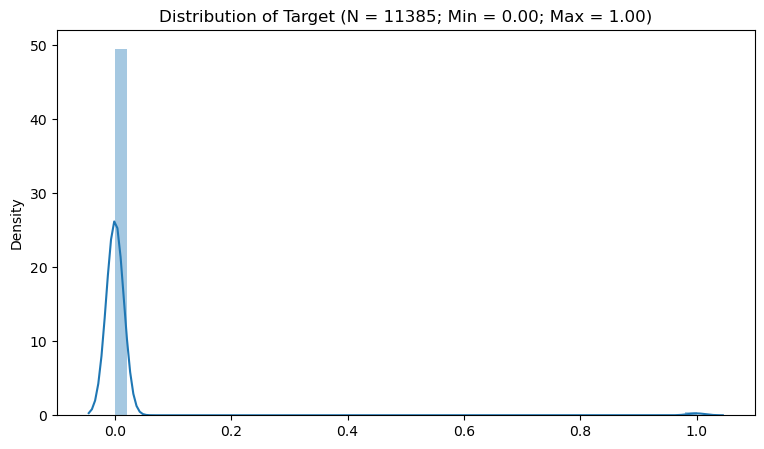

NaN Replacer: 0.053489 sec.
Boolean Replacer: 0.070711 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4455.00it/s]


Data Type Setter: 0.62249 sec.


100%|██████████| 32/32 [00:00<00:00, 124.68it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26748 sec.


...

100%|██████████| 3/3 [00:00<00:00, 1476.52it/s]

Round income (for PTI), amount financed and vehicle values for (LTV): 0.0039624 sec.
Engineer PTI and LTV: 0.0019261 sec.



/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:404: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-payment_to_income'] = X['fltapprovedpayment__app'] / X['fltgrossmonthly__income_sum']
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-loan_to_value'] = X['fltamountfinanced__app'] / X['fltapprovedpricewholesale__app']
100%|██████████| 1556/1556 [00:00<00:00, 2548.17it/s]


Replace inf and -inf with NaN: 0.89211 sec.
Imputer: 0.16672 sec.
Map term: 0.0068924 sec.
Preprocessing Model: 2.8043 sec.


/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


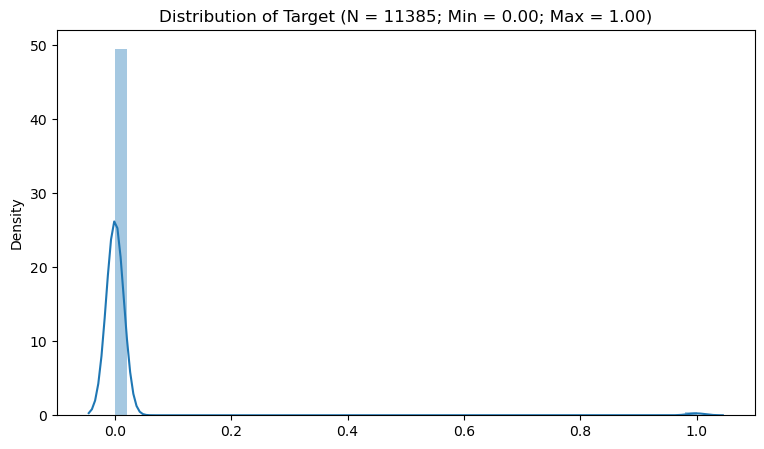

NaN Replacer: 0.053748 sec.
Boolean Replacer: 0.070901 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4482.31it/s]


Data Type Setter: 0.62163 sec.


100%|██████████| 32/32 [00:00<00:00, 124.33it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.26804 sec.


...

Replace zeros with predetermined value: 0.003677 sec.
Date features: 0.011667 sec.


100%|██████████| 3/3 [00:00<00:00, 1479.82it/s]

Round income (for PTI), amount financed and vehicle values for (LTV): 0.0039412 sec.
Engineer PTI and LTV: 0.0019174 sec.



/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:404: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-payment_to_income'] = X['fltapprovedpayment__app'] / X['fltgrossmonthly__income_sum']
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-loan_to_value'] = X['fltamountfinanced__app'] / X['fltapprovedpricewholesale__app']
100%|██████████| 1556/1556 [00:00<00:00, 2551.89it/s]
/tmp/ipykernel_25340/285987

Replace inf and -inf with NaN: 0.88886 sec.
Imputer: 0.16707 sec.
Map term: 0.0068856 sec.
Map PTI: 0.0029632 sec.
Preprocessing Model: 2.8008 sec.


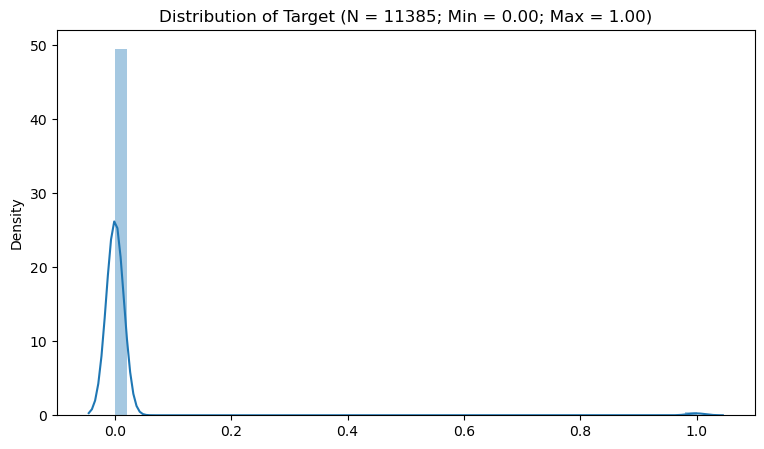

NaN Replacer: 0.053689 sec.
Boolean Replacer: 0.070944 sec.


100%|██████████| 1550/1550 [00:00<00:00, 4450.98it/s]


Data Type Setter: 0.62291 sec.


100%|██████████| 32/32 [00:00<00:00, 123.26it/s]
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:169: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['year'] = X[self.str_datecol].dt.year
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:171: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['factor'] = X['year'].map(self.dict_inflation_rate)


Clean text and impute non-numeric: 0.27036 sec.


...

Round income (for PTI), amount financed and vehicle values for (LTV): 0.0049554 sec.
Engineer PTI and LTV: 0.0020029 sec.



/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:404: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-payment_to_income'] = X['fltapprovedpayment__app'] / X['fltgrossmonthly__income_sum']
/home/ec2-user/SageMaker/20231010_gen_xii/ad_hoc/check_lgd_target/preprocessing.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['ENG-loan_to_value'] = X['fltamountfinanced__app'] / X['fltapprovedpricewholesale__app']
100%|██████████| 1556/1556 [00:00<00:00, 2534.56it/s]


Replace inf and -inf with NaN: 0.89189 sec.
Imputer: 0.1065 sec.
Map term: 0.0071526 sec.
Map PTI: 0.0030164 sec.


100%|██████████| 7/7 [00:00<00:00, 1738.42it/s]
/tmp/ipykernel_25340/2859878331.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


Round values: 0.0068305 sec.
Preprocessing Model: 2.875 sec.


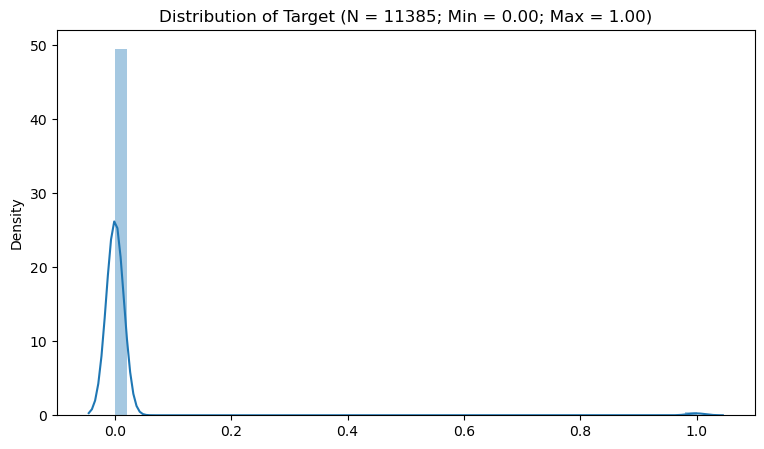

In [15]:
for a in range(len(list_transformers)):
    # subset list
    list_tmp = list_transformers[:a+1].copy()
    # assign
    cls_model_preprocessing.list_transformers = list_tmp
    # import
    str_uri = 's3://20231010-gen-xii/03_pricing_lgd/01_data_prep/05_leaky_features/04_write_dfs/df_test_noleaks.gzip'
    df = pd.read_parquet(str_uri)
    # preprocess
    df = cls_model_preprocessing.transform(df)
    plot_target(ser_target=df['target'])